
# Dynamic Programming for Finite Markov Decision Processes

This notebook introduces **Dynamic Programming (DP)** for reinforcement learning and applies three DP algorithms to the same stochastic robot-navigation problem:

1. **Policy Iteration**
2. **Value Iteration**
3. **Modified Policy Iteration**

The goal is to connect the mathematical equations directly to the numerical calculations and Python implementation.

---

## 1. What is Dynamic Programming?

Dynamic Programming refers to a family of algorithms that solve a decision problem by repeatedly using value functions to break a larger problem into smaller subproblems.

In reinforcement learning, DP is used when the environment is represented as a **known finite Markov Decision Process (MDP)**. This means we know:

- the finite state set $\mathcal{S}$,
- the action set $\mathcal{A}(s)$,
- the transition probabilities $p(s',r\mid s,a)$,
- the rewards,
- and the discount factor $\gamma$.

DP methods use the **Bellman equations** to repeatedly update value estimates until they converge.

A major assumption is that the model of the environment is known. Because of this, DP is mainly a planning method rather than a model-free learning method.



## 2. Mathematical Foundation

### 2.1 State-value function under a policy

For a policy $\pi$, the state-value function is

$$
v_\pi(s)
=
\mathbb{E}_\pi[G_t\mid S_t=s].
$$

Using the Bellman expectation equation,

$$
v_\pi(s)
=
\sum_a \pi(a\mid s)
\sum_{s',r}
p(s',r\mid s,a)
\left[
r+\gamma v_\pi(s')
\right].
$$

For a deterministic policy, where the action is $\pi(s)$,

$$
v_\pi(s)
=
\sum_{s',r}
p(s',r\mid s,\pi(s))
\left[
r+\gamma v_\pi(s')
\right].
$$

In this robot example, the reward is attached to the current state. Therefore the update is written as

$$
V^\pi_{k+1}(s)
=
r(s)
+
\gamma
\sum_{s'}
P(s'\mid s,\pi(s))
V^\pi_k(s').
$$

---

### 2.2 Action-value function under a policy

The action value of taking action $a$ in state $s$ and then following policy $\pi$ is

$$
q_\pi(s,a)
=
\sum_{s',r}
p(s',r\mid s,a)
\left[
r+\gamma v_\pi(s')
\right].
$$

In our state-reward formulation,

$$
Q_\pi(s,a)
=
r(s)
+
\gamma
\sum_{s'}
P(s'\mid s,a)V_\pi(s').
$$

---

### 2.3 Bellman optimality equation for the optimal state value

The optimal value function satisfies

$$
v_*(s)
=
\max_a
\sum_{s',r}
p(s',r\mid s,a)
\left[
r+\gamma v_*(s')
\right].
$$

For this notebook,

$$
V^*(s)
=
r(s)
+
\gamma
\max_a
\sum_{s'}
P(s'\mid s,a)V^*(s').
$$

---

### 2.4 Bellman optimality equation for the optimal action value

The optimal action-value function satisfies

$$
q_*(s,a)
=
\sum_{s',r}
p(s',r\mid s,a)
\left[
r+\gamma \max_{a'} q_*(s',a')
\right].
$$

---

### 2.5 Greedy policy improvement

Once the value function of a policy is known, a better policy can be obtained by choosing the action with the highest one-step look-ahead value:

$$
\pi_{\text{new}}(s)
=
\arg\max_a
\left[
r(s)
+
\gamma
\sum_{s'}
P(s'\mid s,a)V_\pi(s')
\right].
$$

This relationship between **evaluation** and **improvement** is the basis of Policy Iteration.


## 3. The Three Dynamic Programming Algorithms

### 3.1 Policy Iteration

**How it works:** Policy Iteration alternates between two steps. First, it evaluates the current policy until the value function is sufficiently accurate. Then it improves the policy by choosing the greedy action in every state. The process stops when the policy no longer changes.

#### Algorithm: Policy Iteration

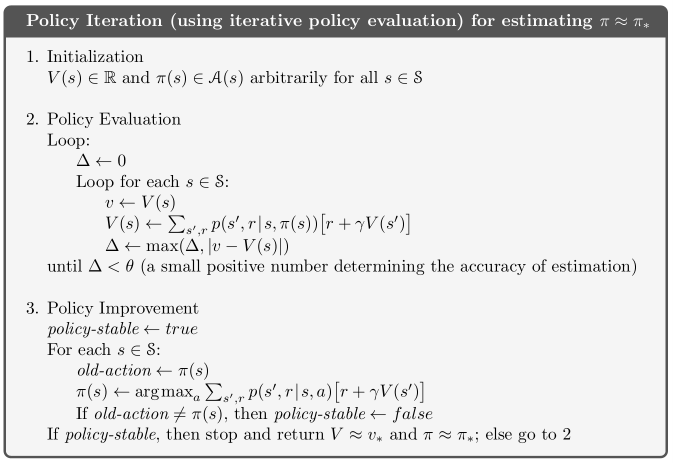
---


## pseudocode (policy iteration)
Input: transition model P, rewards r, discount factor gamma, convergence threshold theta

Initialize: V(s) arbitrarily and policy pi(s) arbitrarily

Repeat:

    1. Policy Evaluation

    Repeat:
        Delta = 0
        For each state s:
            if s is terminal: V_new(s) = r(s)
            else: V_new(s) = r(s) + gamma * sum over s' [P(s' | s, pi(s)) * V(s')]
            Delta = max(Delta, |V_new(s) - V(s)|)
        V = V_new

    Until Delta < theta

    2. Policy Improvement

    policy_stable = True

    For each nonterminal state s:
        old_action = pi(s)
        pi_new(s) = argmax over a [r(s) + gamma * sum over s' [P(s' | s, a) * V(s')]]
        if old_action != pi_new(s): policy_stable = False

    pi = pi_new

Until policy_stable = True

Output: optimal value function V* and optimal policy pi*


### 3.2 Value Iteration

**How it works:** Value Iteration combines policy evaluation and policy improvement in one Bellman optimality update. At every sweep, each state is updated using the action that gives the highest expected value. After the values converge, the optimal policy is extracted using a greedy action selection.

#### Algorithm: Value Iteration
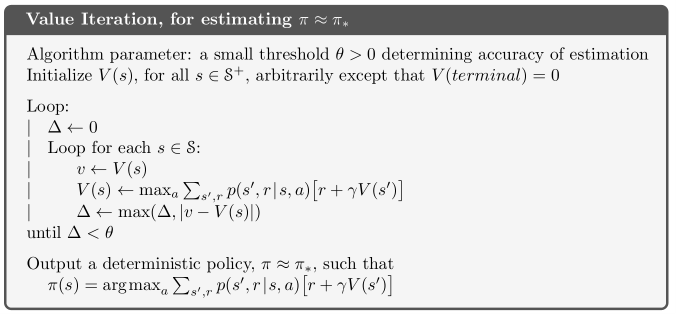

## pseudocode (value iteration)
Input: transition model P, rewards r, discount factor gamma, convergence threshold theta

Initialize: V(s) arbitrarily

Repeat:

    Delta = 0

    For each state s:
        if s is terminal: V_new(s) = r(s)
        else: V_new(s) = max over a [r(s) + gamma * sum over s' [P(s' | s, a) * V(s')]]
        Delta = max(Delta, |V_new(s) - V(s)|)

    V = V_new

Until Delta < theta

For each nonterminal state s:
    pi*(s) = argmax over a [r(s) + gamma * sum over s' [P(s' | s, a) * V(s')]]

Output: optimal value function V* and optimal policy pi*


### 3.3 Modified Policy Iteration

**How it works:** Modified Policy Iteration lies between Policy Iteration and Value Iteration. Instead of evaluating a policy all the way to convergence, it performs only a fixed number $K$ of policy-evaluation sweeps and then improves the policy.

When $K$ is small, the method behaves more like Value Iteration. When policy evaluation is continued to convergence, it approaches ordinary Policy Iteration.

#### Algorithm: Modified Policy Iteration

Input: transition model P, rewards r, discount factor gamma, evaluation sweeps K, convergence threshold theta

Initialize: V(s) arbitrarily and policy pi(s) arbitrarily

Repeat:

    1. Partial Policy Evaluation

    Repeat K times:
        For each state s:
            if s is terminal: V_new(s) = r(s)
            else: V_new(s) = r(s) + gamma * sum over s' [P(s' | s, pi(s)) * V(s')]
        V = V_new

    2. Policy Improvement

    For each nonterminal state s:
        pi_new(s) = argmax over a [r(s) + gamma * sum over s' [P(s' | s, a) * V(s')]]

    3. Check Convergence

    Compute the Bellman optimality residual

Until the policy is stable and Bellman residual < theta

Output: optimal value function V* and optimal policy pi*


# 4. Robot Navigation Problem
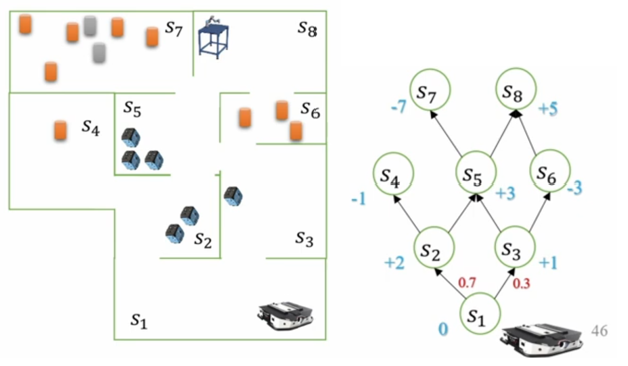



Consider a robot moving through an eight-state environment.

The state set is

$$
\mathcal{S}
=
\{s_1,s_2,s_3,s_4,s_5,s_6,s_7,s_8\}.
$$

At each nonterminal decision state, the robot chooses one of two actions:

$$
\mathcal{A}=\{L,R\}.
$$

The environment is stochastic.

- If the robot chooses **Left**, it follows the left branch with probability $0.7$ and the other branch with probability $0.3$.
- If the robot chooses **Right**, it follows the right branch with probability $0.7$ and the other branch with probability $0.3$.
- From $s_6$, both actions lead to $s_8$ with probability $1$.
- States $s_4$, $s_7$, and $s_8$ are terminal.

The state rewards are

$$
r(s_1)=0,\quad
r(s_2)=2,\quad
r(s_3)=1,\quad
r(s_4)=-1,
$$

$$
r(s_5)=3,\quad
r(s_6)=-3,\quad
r(s_7)=-7,\quad
r(s_8)=5.
$$

We use

$$
\gamma=0.9
$$

and the convergence threshold

$$
\theta=0.01.
$$

For consistency with the lecture example, terminal-state values are fixed at their terminal rewards.


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from IPython.display import display
states = [f's{i}' for i in range(1, 9)]
state_index = {s: i for i, s in enumerate(states)}
actions = ['L', 'R']
rewards = np.array([0, 2, 1, -1, 3, -3, -7, 5], dtype=float)
gamma = 0.9
theta = 0.01
terminal_states = {'s4', 's7', 's8'}
terminal_idx = {state_index[s] for s in terminal_states}
P_left = np.array([[0, 0.7, 0.3, 0, 0, 0, 0, 0], [0, 0, 0, 0.7, 0.3, 0, 0, 0], [0, 0, 0, 0, 0.7, 0.3, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0.7, 0.3], [0, 0, 0, 0, 0, 0, 0, 1.0], [0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0]], dtype=float)
P_right = np.array([[0, 0.3, 0.7, 0, 0, 0, 0, 0], [0, 0, 0, 0.3, 0.7, 0, 0, 0], [0, 0, 0, 0, 0.3, 0.7, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0.3, 0.7], [0, 0, 0, 0, 0, 0, 0, 1.0], [0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0]], dtype=float)
P = {'L': P_left, 'R': P_right}
print('States:', states)
print('Actions:', actions)
print('Rewards:', rewards.tolist())
print('Terminal states:', sorted(terminal_states))
print('gamma =', gamma)
print('theta =', theta)

States: ['s1', 's2', 's3', 's4', 's5', 's6', 's7', 's8']
Actions: ['L', 'R']
Rewards: [0.0, 2.0, 1.0, -1.0, 3.0, -3.0, -7.0, 5.0]
Terminal states: ['s4', 's7', 's8']
gamma = 0.9
theta = 0.01


## 4.1 Transition probability matrices

In [11]:
print('Transition matrix for action Left')
display(pd.DataFrame(P_left, index=states, columns=states))
print('Transition matrix for action Right')
display(pd.DataFrame(P_right, index=states, columns=states))

Transition matrix for action Left


,s1,s2,s3,s4,s5,s6,s7,s8
s1,0.0,0.7,0.3,0.0,0.0,0.0,0.0,0.0
s2,0.0,0.0,0.0,0.7,0.3,0.0,0.0,0.0
s3,0.0,0.0,0.0,0.0,0.7,0.3,0.0,0.0
s4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
s5,0.0,0.0,0.0,0.0,0.0,0.0,0.7,0.3
s6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
s7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
s8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Transition matrix for action Right


,s1,s2,s3,s4,s5,s6,s7,s8
s1,0.0,0.3,0.7,0.0,0.0,0.0,0.0,0.0
s2,0.0,0.0,0.0,0.3,0.7,0.0,0.0,0.0
s3,0.0,0.0,0.0,0.0,0.3,0.7,0.0,0.0
s4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
s5,0.0,0.0,0.0,0.0,0.0,0.0,0.3,0.7
s6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
s7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
s8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



For example, from $s_1$:

If the robot chooses **Left**,

$$
P(s_2\mid s_1,L)=0.7,
\qquad
P(s_3\mid s_1,L)=0.3.
$$

If it chooses **Right**,

$$
P(s_2\mid s_1,R)=0.3,
\qquad
P(s_3\mid s_1,R)=0.7.
$$


In [12]:
transition_rows = [['s1', '0.7→s2, 0.3→s3', '0.3→s2, 0.7→s3'], ['s2', '0.7→s4, 0.3→s5', '0.3→s4, 0.7→s5'], ['s3', '0.7→s5, 0.3→s6', '0.3→s5, 0.7→s6'], ['s4', 'terminal', 'terminal'], ['s5', '0.7→s7, 0.3→s8', '0.3→s7, 0.7→s8'], ['s6', '1.0→s8', '1.0→s8'], ['s7', 'terminal', 'terminal'], ['s8', 'terminal', 'terminal']]
display(pd.DataFrame(transition_rows, columns=['State', 'Left', 'Right']))

,State,Left,Right
0,s1,"0.7→s2, 0.3→s3","0.3→s2, 0.7→s3"
1,s2,"0.7→s4, 0.3→s5","0.3→s4, 0.7→s5"
2,s3,"0.7→s5, 0.3→s6","0.3→s5, 0.7→s6"
3,s4,terminal,terminal
4,s5,"0.7→s7, 0.3→s8","0.3→s7, 0.7→s8"
5,s6,1.0→s8,1.0→s8
6,s7,terminal,terminal
7,s8,terminal,terminal


## 4.2 MDP structure

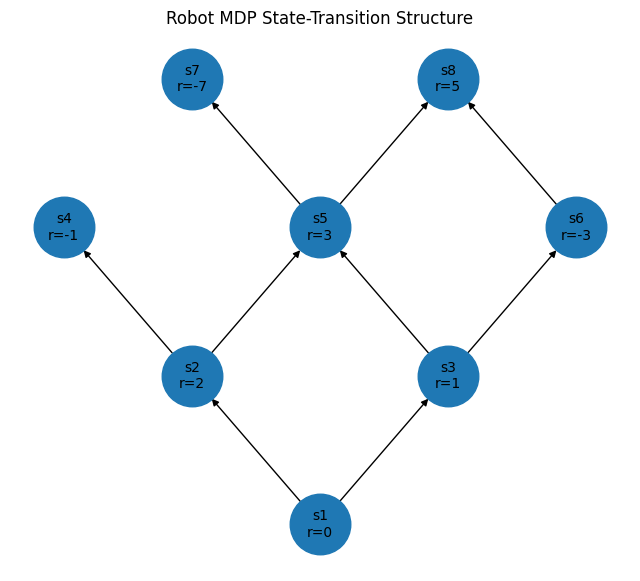

In [13]:
G = nx.DiGraph()
for s in states:
    G.add_node(s)
edges = [('s1', 's2'), ('s1', 's3'), ('s2', 's4'), ('s2', 's5'), ('s3', 's5'), ('s3', 's6'), ('s5', 's7'), ('s5', 's8'), ('s6', 's8')]
G.add_edges_from(edges)
pos = {'s1': (0, 0), 's2': (-1, 1), 's3': (1, 1), 's4': (-2, 2), 's5': (0, 2), 's6': (2, 2), 's7': (-1, 3), 's8': (1, 3)}
labels = {s: f'{s}\nr={int(rewards[state_index[s]])}' for s in states}
plt.figure(figsize=(8, 7))
nx.draw_networkx(G, pos=pos, labels=labels, arrows=True, node_size=1900, font_size=10)
plt.title('Robot MDP State-Transition Structure')
plt.axis('off')
plt.show()


# 5. Helper Functions for Showing Every Calculation

The functions below keep the numerical work transparent. Each sweep returns a table showing:

- the current state,
- the current action,
- the immediate reward,
- the expected next-state value,
- the discounted future value,
- the updated value,
- and the change from the previous sweep.

For improvement steps, the notebook calculates both $Q(s,L)$ and $Q(s,R)$ before selecting an action.


In [14]:
def weighted_terms(probabilities, values):
    terms = []
    for j, p in enumerate(probabilities):
        if p > 0:
            terms.append(f'{p:.1f}×{values[j]:.4f}')
    return ' + '.join(terms) if terms else '0'

def policy_evaluation_sweep(V, policy):
    V_old = V.copy()
    V_new = V_old.copy()
    rows = []
    for i, s in enumerate(states):
        if i in terminal_idx:
            V_new[i] = rewards[i]
            rows.append({'State': s, 'Action': '-', 'Calculation': f'{rewards[i]:.1f}  (terminal)', 'New V': V_new[i], '|Change|': abs(V_new[i] - V_old[i])})
        else:
            a = policy[i]
            expectation = P[a][i] @ V_old
            V_new[i] = rewards[i] + gamma * expectation
            rows.append({'State': s, 'Action': a, 'Calculation': f'{rewards[i]:.1f} + {gamma:.1f}×({weighted_terms(P[a][i], V_old)})', 'New V': V_new[i], '|Change|': abs(V_new[i] - V_old[i])})
    delta = np.max(np.abs(V_new - V_old))
    return (V_new, delta, pd.DataFrame(rows))

def q_value(s_idx, action, V):
    return rewards[s_idx] + gamma * (P[action][s_idx] @ V)

def policy_improvement_table(V, policy):
    new_policy = policy.copy()
    rows = []
    for i, s in enumerate(states):
        if i in terminal_idx:
            new_policy[i] = '-'
            rows.append({'State': s, 'Q(L) calculation': 'terminal', 'Q(L)': np.nan, 'Q(R) calculation': 'terminal', 'Q(R)': np.nan, 'Old action': '-', 'New action': '-'})
            continue
        qL = q_value(i, 'L', V)
        qR = q_value(i, 'R', V)
        best = 'L' if qL >= qR else 'R'
        old = policy[i]
        new_policy[i] = best
        rows.append({'State': s, 'Q(L) calculation': f'{rewards[i]:.1f} + {gamma:.1f}×({weighted_terms(P_left[i], V)})', 'Q(L)': qL, 'Q(R) calculation': f'{rewards[i]:.1f} + {gamma:.1f}×({weighted_terms(P_right[i], V)})', 'Q(R)': qR, 'Old action': old, 'New action': best})
    return (new_policy, pd.DataFrame(rows))

def value_iteration_sweep(V):
    V_old = V.copy()
    V_new = V_old.copy()
    rows = []
    for i, s in enumerate(states):
        if i in terminal_idx:
            V_new[i] = rewards[i]
            rows.append({'State': s, 'Q(L)': np.nan, 'Q(R)': np.nan, 'Selected': '-', 'New V': V_new[i], 'Calculation': f'{rewards[i]:.1f}  (terminal)'})
            continue
        qL = q_value(i, 'L', V_old)
        qR = q_value(i, 'R', V_old)
        if qL >= qR:
            best_action, best_value = ('L', qL)
        else:
            best_action, best_value = ('R', qR)
        V_new[i] = best_value
        rows.append({'State': s, 'Q(L)': qL, 'Q(R)': qR, 'Selected': best_action, 'New V': best_value, 'Calculation': f'max[{qL:.4f}, {qR:.4f}] = {best_value:.4f}'})
    delta = np.max(np.abs(V_new - V_old))
    return (V_new, delta, pd.DataFrame(rows))

def greedy_policy(V):
    policy = np.array(['-'] * len(states), dtype=object)
    for i in range(len(states)):
        if i in terminal_idx:
            continue
        qL = q_value(i, 'L', V)
        qR = q_value(i, 'R', V)
        policy[i] = 'L' if qL >= qR else 'R'
    return policy

def bellman_optimality_residual(V):
    target = V.copy()
    for i in range(len(states)):
        if i in terminal_idx:
            target[i] = rewards[i]
        else:
            target[i] = max(q_value(i, 'L', V), q_value(i, 'R', V))
    return np.max(np.abs(target - V))

def value_table(V, name='V'):
    return pd.DataFrame([V], index=[name], columns=states)


# 6. Policy Iteration

We begin with the same initial policy used in the example:

$$
\pi_0=
[R,\;R,\;R,\;-,\;R,\;R,\;-,\;-].
$$

We also initialize

$$
V_0(s)=0
$$

for all states.

Policy Iteration will:

1. evaluate $\pi_0$ until $\Delta<\theta$,
2. improve the policy,
3. evaluate the new policy,
4. repeat until the policy is stable.


In [15]:
initial_policy = np.array(['R', 'R', 'R', '-', 'R', 'R', '-', '-'], dtype=object)
display(pd.DataFrame([initial_policy], index=['Initial policy'], columns=states))

,s1,s2,s3,s4,s5,s6,s7,s8
Initial policy,R,R,R,-,R,R,-,-



## 6.1 First policy-evaluation sweep

For $s_1$, the current policy chooses $R$. Because all initial values are zero,

$$
V_1^{\pi_0}(s_1)
=
0
+
0.9
\left[
0.3V_0(s_2)+0.7V_0(s_3)
\right]
=0.
$$

For $s_2$,

$$
V_1^{\pi_0}(s_2)
=
2
+
0.9
\left[
0.3V_0(s_4)+0.7V_0(s_5)
\right]
=2.
$$

The code below shows the calculation for **every state** in every evaluation sweep.


In [16]:
def run_policy_iteration(initial_policy, theta=0.01):
    policy = initial_policy.copy()
    outer_history = []
    total_eval_sweeps = 0
    for outer in range(1, 100):
        V = np.zeros(len(states), dtype=float)
        eval_history = []
        while True:
            V, delta, table = policy_evaluation_sweep(V, policy)
            total_eval_sweeps += 1
            eval_history.append({'V': V.copy(), 'delta': delta, 'table': table})
            if delta < theta:
                break
        improved_policy, improvement_table = policy_improvement_table(V, policy)
        stable = np.array_equal(improved_policy, policy)
        outer_history.append({'outer': outer, 'policy_before': policy.copy(), 'eval_history': eval_history, 'V': V.copy(), 'improvement_table': improvement_table, 'policy_after': improved_policy.copy(), 'stable': stable})
        policy = improved_policy
        if stable:
            break
    return (V, policy, outer_history, total_eval_sweeps)
V_pi, policy_pi, pi_history, pi_total_sweeps = run_policy_iteration(initial_policy, theta)
for record in pi_history:
    print('=' * 90)
    print(f"POLICY ITERATION OUTER ITERATION {record['outer']}")
    print('Policy being evaluated:')
    display(pd.DataFrame([record['policy_before']], index=[f"pi_{record['outer'] - 1}"], columns=states))
    for sweep_no, sweep in enumerate(record['eval_history'], start=1):
        print(f'Policy-evaluation sweep {sweep_no}')
        display(sweep['table'].round(4))
        print(f"Delta = {sweep['delta']:.6f}")
        display(value_table(sweep['V'], f'V after sweep {sweep_no}').round(4))
    print('Policy improvement: compare Left and Right in every nonterminal state')
    display(record['improvement_table'].round(4))
    print('Improved policy:')
    display(pd.DataFrame([record['policy_after']], index=['Improved policy'], columns=states))
    print('Policy stable:', record['stable'])

POLICY ITERATION OUTER ITERATION 1
Policy being evaluated:


,s1,s2,s3,s4,s5,s6,s7,s8
pi_0,R,R,R,-,R,R,-,-


Policy-evaluation sweep 1


,State,Action,Calculation,New V,|Change|
0,s1,R,0.0 + 0.9×(0.3×0.0000 + 0.7×0.0000),0.0,0.0
1,s2,R,2.0 + 0.9×(0.3×0.0000 + 0.7×0.0000),2.0,2.0
2,s3,R,1.0 + 0.9×(0.3×0.0000 + 0.7×0.0000),1.0,1.0
3,s4,-,-1.0 (terminal),-1.0,1.0
4,s5,R,3.0 + 0.9×(0.3×0.0000 + 0.7×0.0000),3.0,3.0
5,s6,R,-3.0 + 0.9×(1.0×0.0000),-3.0,3.0
6,s7,-,-7.0 (terminal),-7.0,7.0
7,s8,-,5.0 (terminal),5.0,5.0


Delta = 7.000000


...

Policy improvement: compare Left and Right in every nonterminal state


,State,Q(L) calculation,Q(L),Q(R) calculation,Q(R),Old action,New action
0,s1,0.0 + 0.9×(0.7×4.4138 + 0.3×4.0888),3.8847,0.0 + 0.9×(0.3×4.4138 + 0.7×4.0888),3.7677,L,L
1,s2,2.0 + 0.9×(0.7×-1.0000 + 0.3×4.2600),2.5202,2.0 + 0.9×(0.3×-1.0000 + 0.7×4.2600),4.4138,R,R
2,s3,1.0 + 0.9×(0.7×4.2600 + 0.3×1.5000),4.0888,1.0 + 0.9×(0.3×4.2600 + 0.7×1.5000),3.0952,L,L
3,s4,terminal,NaN,terminal,NaN,-,-
4,s5,3.0 + 0.9×(0.7×-7.0000 + 0.3×5.0000),-0.0600,3.0 + 0.9×(0.3×-7.0000 + 0.7×5.0000),4.2600,R,R
5,s6,-3.0 + 0.9×(1.0×5.0000),1.5000,-3.0 + 0.9×(1.0×5.0000),1.5000,L,L
6,s7,terminal,NaN,terminal,NaN,-,-
7,s8,terminal,NaN,terminal,NaN,-,-


Improved policy:


,s1,s2,s3,s4,s5,s6,s7,s8
Improved policy,L,R,L,-,R,L,-,-


Policy stable: True



## 6.2 Example of the first policy-improvement calculation

After evaluating the initial policy, the value function is approximately

$$
V^{\pi_0}
=
[3.1417,\;4.4138,\;3.0952,\;-1,\;4.26,\;1.5,\;-7,\;5].
$$

At $s_1$:

### Choose Left

$$
Q_{\pi_0}(s_1,L)
=
0
+
0.9
\left[
0.7(4.4138)
+
0.3(3.0952)
\right]
$$

$$
Q_{\pi_0}(s_1,L)
\approx
3.6164.
$$

### Choose Right

$$
Q_{\pi_0}(s_1,R)
=
0
+
0.9
\left[
0.3(4.4138)
+
0.7(3.0952)
\right]
$$

$$
Q_{\pi_0}(s_1,R)
\approx
3.1417.
$$

Because

$$
3.6164>3.1417,
$$

the improved action at $s_1$ is

$$
\pi_1(s_1)=L.
$$


## 6.3 Final Policy Iteration result

In [17]:
print('Policy Iteration converged.')
display(value_table(V_pi, 'Optimal V from Policy Iteration').round(4))
display(pd.DataFrame([policy_pi], index=['Optimal policy'], columns=states))
print('Outer policy iterations:', len(pi_history))
print('Total policy-evaluation sweeps:', pi_total_sweeps)

Policy Iteration converged.


,s1,s2,s3,s4,s5,s6,s7,s8
Optimal V from Policy Iteration,3.8847,4.4138,4.0888,-1.0,4.26,1.5,-7.0,5.0


,s1,s2,s3,s4,s5,s6,s7,s8
Optimal policy,L,R,L,-,R,L,-,-


Outer policy iterations: 2
Total policy-evaluation sweeps: 10



# 7. Value Iteration

Value Iteration does not fully evaluate a separate policy before improving it.

Instead, it applies the Bellman optimality update directly:

$$
V_{k+1}(s)
=
r(s)
+
\gamma
\max_a
\sum_{s'}
P(s'\mid s,a)V_k(s').
$$

For each state we compute the value of both actions and immediately keep the larger value.



## 7.1 First sweep

Because $V_0(s)=0$ for all states, every nonterminal state's future-value term is initially zero.

For example,

$$
V_1(s_2)
=
2
+
0.9
\max
\left[
0.7(0)+0.3(0),
\;
0.3(0)+0.7(0)
\right]
=2.
$$

After the first sweep,

$$
V_1
=
[0,\;2,\;1,\;-1,\;3,\;-3,\;-7,\;5].
$$

---

## 7.2 Second sweep: example for $s_1$

Using the first-sweep values,

### Left

$$
Q(s_1,L)
=
0
+
0.9
\left[
0.7(2)+0.3(1)
\right]
=
1.53.
$$

### Right

$$
Q(s_1,R)
=
0
+
0.9
\left[
0.3(2)+0.7(1)
\right]
=
1.17.
$$

Therefore,

$$
V_2(s_1)
=
\max(1.53,1.17)
=
1.53.
$$


In [18]:
def run_value_iteration(theta=0.01):
    V = np.zeros(len(states), dtype=float)
    history = []
    for sweep in range(1, 100):
        V, delta, table = value_iteration_sweep(V)
        history.append({'sweep': sweep, 'V': V.copy(), 'delta': delta, 'table': table})
        if delta < theta:
            break
    policy = greedy_policy(V)
    return (V, policy, history)
V_vi, policy_vi, vi_history = run_value_iteration(theta)
for record in vi_history:
    print('=' * 90)
    print(f"VALUE ITERATION SWEEP {record['sweep']}")
    display(record['table'].round(4))
    print(f"Delta = {record['delta']:.6f}")
    display(value_table(record['V'], f"V_{record['sweep']}").round(4))

VALUE ITERATION SWEEP 1


,State,Q(L),Q(R),Selected,New V,Calculation
0,s1,0.0,0.0,L,0.0,"max[0.0000, 0.0000] = 0.0000"
1,s2,2.0,2.0,L,2.0,"max[2.0000, 2.0000] = 2.0000"
2,s3,1.0,1.0,L,1.0,"max[1.0000, 1.0000] = 1.0000"
3,s4,NaN,NaN,-,-1.0,-1.0 (terminal)
4,s5,3.0,3.0,L,3.0,"max[3.0000, 3.0000] = 3.0000"
5,s6,-3.0,-3.0,L,-3.0,"max[-3.0000, -3.0000] = -3.0000"
6,s7,NaN,NaN,-,-7.0,-7.0 (terminal)
7,s8,NaN,NaN,-,5.0,5.0 (terminal)


Delta = 7.000000


,s1,s2,s3,s4,s5,s6,s7,s8
V_1,0.0,2.0,1.0,-1.0,3.0,-3.0,-7.0,5.0


VALUE ITERATION SWEEP 2


...

,s1,s2,s3,s4,s5,s6,s7,s8
V_4,3.8847,4.4138,4.0888,-1.0,4.26,1.5,-7.0,5.0


VALUE ITERATION SWEEP 5


,State,Q(L),Q(R),Selected,New V,Calculation
0,s1,3.8847,3.7677,L,3.8847,"max[3.8847, 3.7677] = 3.8847"
1,s2,2.5202,4.4138,R,4.4138,"max[2.5202, 4.4138] = 4.4138"
2,s3,4.0888,3.0952,L,4.0888,"max[4.0888, 3.0952] = 4.0888"
3,s4,NaN,NaN,-,-1.0000,-1.0 (terminal)
4,s5,-0.0600,4.2600,R,4.2600,"max[-0.0600, 4.2600] = 4.2600"
5,s6,1.5000,1.5000,L,1.5000,"max[1.5000, 1.5000] = 1.5000"
6,s7,NaN,NaN,-,-7.0000,-7.0 (terminal)
7,s8,NaN,NaN,-,5.0000,5.0 (terminal)


Delta = 0.000000


,s1,s2,s3,s4,s5,s6,s7,s8
V_5,3.8847,4.4138,4.0888,-1.0,4.26,1.5,-7.0,5.0



## 7.3 Extract the optimal policy

After the value function converges, the optimal action in each state is

$$
\pi^*(s)
=
\arg\max_a
\left[
r(s)
+
\gamma
\sum_{s'}
P(s'\mid s,a)V^*(s')
\right].
$$

For $s_1$:

$$
Q(s_1,L)
=
0
+
0.9
\left[
0.7(4.4138)
+
0.3(4.0888)
\right]
\approx 3.8847,
$$

while

$$
Q(s_1,R)
=
0
+
0.9
\left[
0.3(4.4138)
+
0.7(4.0888)
\right]
\approx 3.7677.
$$

Thus,

$$
\pi^*(s_1)=L.
$$


In [19]:
_, final_vi_policy_table = policy_improvement_table(V_vi, np.array(['-'] * len(states), dtype=object))
print('Greedy action calculation after Value Iteration convergence')
display(final_vi_policy_table.round(4))
display(value_table(V_vi, 'Optimal V from Value Iteration').round(4))
display(pd.DataFrame([policy_vi], index=['Optimal policy'], columns=states))

Greedy action calculation after Value Iteration convergence


,State,Q(L) calculation,Q(L),Q(R) calculation,Q(R),Old action,New action
0,s1,0.0 + 0.9×(0.7×4.4138 + 0.3×4.0888),3.8847,0.0 + 0.9×(0.3×4.4138 + 0.7×4.0888),3.7677,-,L
1,s2,2.0 + 0.9×(0.7×-1.0000 + 0.3×4.2600),2.5202,2.0 + 0.9×(0.3×-1.0000 + 0.7×4.2600),4.4138,-,R
2,s3,1.0 + 0.9×(0.7×4.2600 + 0.3×1.5000),4.0888,1.0 + 0.9×(0.3×4.2600 + 0.7×1.5000),3.0952,-,L
3,s4,terminal,NaN,terminal,NaN,-,-
4,s5,3.0 + 0.9×(0.7×-7.0000 + 0.3×5.0000),-0.0600,3.0 + 0.9×(0.3×-7.0000 + 0.7×5.0000),4.2600,-,R
5,s6,-3.0 + 0.9×(1.0×5.0000),1.5000,-3.0 + 0.9×(1.0×5.0000),1.5000,-,L
6,s7,terminal,NaN,terminal,NaN,-,-
7,s8,terminal,NaN,terminal,NaN,-,-


,s1,s2,s3,s4,s5,s6,s7,s8
Optimal V from Value Iteration,3.8847,4.4138,4.0888,-1.0,4.26,1.5,-7.0,5.0


,s1,s2,s3,s4,s5,s6,s7,s8
Optimal policy,L,R,L,-,R,L,-,-



# 8. Modified Policy Iteration

For this example, choose

$$
K=2.
$$

Therefore each outer iteration performs:

1. two policy-evaluation sweeps,
2. one policy-improvement step,
3. a convergence check.

The initial policy is again

$$
\pi_0=
[R,\;R,\;R,\;-,\;R,\;R,\;-,\;-].
$$



## 8.1 First partial evaluation

After the first two evaluation sweeps under $\pi_0$,

$$
V
=
[1.17,\;3.62,\;-0.08,\;-1,\;4.26,\;1.5,\;-7,\;5].
$$

Now improve the policy.

At $s_1$:

### Left

$$
Q(s_1,L)
=
0
+
0.9
\left[
0.7(3.62)
+
0.3(-0.08)
\right]
=
2.259.
$$

### Right

$$
Q(s_1,R)
=
0
+
0.9
\left[
0.3(3.62)
+
0.7(-0.08)
\right]
=
0.927.
$$

Therefore,

$$
\pi_1(s_1)=L.
$$

The notebook computes the same comparison for every nonterminal state.


In [20]:
def run_modified_policy_iteration(initial_policy, K=2, theta=0.01):
    V = np.zeros(len(states), dtype=float)
    policy = initial_policy.copy()
    history = []
    total_eval_sweeps = 0
    for outer in range(1, 100):
        eval_history = []
        for local_sweep in range(1, K + 1):
            V, delta, table = policy_evaluation_sweep(V, policy)
            total_eval_sweeps += 1
            eval_history.append({'local_sweep': local_sweep, 'V': V.copy(), 'delta': delta, 'table': table})
        improved_policy, improvement_table = policy_improvement_table(V, policy)
        stable = np.array_equal(improved_policy, policy)
        residual = bellman_optimality_residual(V)
        history.append({'outer': outer, 'policy_before': policy.copy(), 'eval_history': eval_history, 'policy_after': improved_policy.copy(), 'improvement_table': improvement_table, 'stable': stable, 'residual': residual})
        policy = improved_policy
        if stable and residual < theta:
            break
    return (V, policy, history, total_eval_sweeps)
K = 2
V_mpi, policy_mpi, mpi_history, mpi_total_sweeps = run_modified_policy_iteration(initial_policy, K=K, theta=theta)
for record in mpi_history:
    print('=' * 90)
    print(f"MODIFIED POLICY ITERATION OUTER ITERATION {record['outer']}")
    print('Policy being partially evaluated:')
    display(pd.DataFrame([record['policy_before']], index=['Current policy'], columns=states))
    for sweep in record['eval_history']:
        print(f"Partial policy-evaluation sweep {sweep['local_sweep']} of K={K}")
        display(sweep['table'].round(4))
        print(f"Delta = {sweep['delta']:.6f}")
        display(value_table(sweep['V'], f"V after partial sweep {sweep['local_sweep']}").round(4))
    print('Policy improvement')
    display(record['improvement_table'].round(4))
    print('Improved policy')
    display(pd.DataFrame([record['policy_after']], index=['Improved policy'], columns=states))
    print('Policy stable:', record['stable'])
    print(f"Bellman optimality residual = {record['residual']:.6f}")

MODIFIED POLICY ITERATION OUTER ITERATION 1
Policy being partially evaluated:


,s1,s2,s3,s4,s5,s6,s7,s8
Current policy,R,R,R,-,R,R,-,-


Partial policy-evaluation sweep 1 of K=2


,State,Action,Calculation,New V,|Change|
0,s1,R,0.0 + 0.9×(0.3×0.0000 + 0.7×0.0000),0.0,0.0
1,s2,R,2.0 + 0.9×(0.3×0.0000 + 0.7×0.0000),2.0,2.0
2,s3,R,1.0 + 0.9×(0.3×0.0000 + 0.7×0.0000),1.0,1.0
3,s4,-,-1.0 (terminal),-1.0,1.0
4,s5,R,3.0 + 0.9×(0.3×0.0000 + 0.7×0.0000),3.0,3.0
5,s6,R,-3.0 + 0.9×(1.0×0.0000),-3.0,3.0
6,s7,-,-7.0 (terminal),-7.0,7.0
7,s8,-,5.0 (terminal),5.0,5.0


Delta = 7.000000


...

Policy improvement


,State,Q(L) calculation,Q(L),Q(R) calculation,Q(R),Old action,New action
0,s1,0.0 + 0.9×(0.7×4.4138 + 0.3×4.0888),3.8847,0.0 + 0.9×(0.3×4.4138 + 0.7×4.0888),3.7677,L,L
1,s2,2.0 + 0.9×(0.7×-1.0000 + 0.3×4.2600),2.5202,2.0 + 0.9×(0.3×-1.0000 + 0.7×4.2600),4.4138,R,R
2,s3,1.0 + 0.9×(0.7×4.2600 + 0.3×1.5000),4.0888,1.0 + 0.9×(0.3×4.2600 + 0.7×1.5000),3.0952,L,L
3,s4,terminal,NaN,terminal,NaN,-,-
4,s5,3.0 + 0.9×(0.7×-7.0000 + 0.3×5.0000),-0.0600,3.0 + 0.9×(0.3×-7.0000 + 0.7×5.0000),4.2600,R,R
5,s6,-3.0 + 0.9×(1.0×5.0000),1.5000,-3.0 + 0.9×(1.0×5.0000),1.5000,L,L
6,s7,terminal,NaN,terminal,NaN,-,-
7,s8,terminal,NaN,terminal,NaN,-,-


Improved policy


,s1,s2,s3,s4,s5,s6,s7,s8
Improved policy,L,R,L,-,R,L,-,-


Policy stable: True
Bellman optimality residual = 0.000000


## 8.2 Final Modified Policy Iteration result

In [21]:
display(value_table(V_mpi, 'Optimal V from Modified Policy Iteration').round(4))
display(pd.DataFrame([policy_mpi], index=['Optimal policy'], columns=states))
print('Modified Policy Iteration outer iterations:', len(mpi_history))
print('Total partial policy-evaluation sweeps:', mpi_total_sweeps)

,s1,s2,s3,s4,s5,s6,s7,s8
Optimal V from Modified Policy Iteration,3.8847,4.4138,4.0888,-1.0,4.26,1.5,-7.0,5.0


,s1,s2,s3,s4,s5,s6,s7,s8
Optimal policy,L,R,L,-,R,L,-,-


Modified Policy Iteration outer iterations: 2
Total partial policy-evaluation sweeps: 4



# 9. Compare the Three Algorithms

All three methods should converge to the same optimal solution for this finite MDP.

For this example,

$$
V^*
\approx
[3.8847,\;4.4138,\;4.0888,\;-1,\;4.26,\;1.5,\;-7,\;5]
$$

and

$$
\pi^*
=
[L,\;R,\;L,\;-,\;R,\;L,\;-,\;-].
$$

The number of sweeps should be interpreted carefully:

- Policy Iteration may use fewer **policy improvements**, but each policy can require several evaluation sweeps.
- Value Iteration performs one optimality sweep at a time.
- Modified Policy Iteration limits policy evaluation to $K$ sweeps before improvement.

The counts below apply only to this small robot MDP with $\theta=0.01$ and $K=2$.


In [22]:
comparison = pd.DataFrame({'Algorithm': ['Policy Iteration', 'Value Iteration', 'Modified Policy Iteration'], 'Value-update sweeps': [pi_total_sweeps, len(vi_history), mpi_total_sweeps], 'Policy-improvement steps': [len(pi_history), 1, len(mpi_history)], 'Final Bellman residual': [bellman_optimality_residual(V_pi), bellman_optimality_residual(V_vi), bellman_optimality_residual(V_mpi)]})
display(comparison.round(6))

,Algorithm,Value-update sweeps,Policy-improvement steps,Final Bellman residual
0,Policy Iteration,10,2,0.0
1,Value Iteration,5,1,0.0
2,Modified Policy Iteration,4,2,0.0


In [23]:
values_comparison = pd.DataFrame({'Policy Iteration': V_pi, 'Value Iteration': V_vi, 'Modified Policy Iteration': V_mpi}, index=states)
display(values_comparison.round(4))
policies_comparison = pd.DataFrame({'Policy Iteration': policy_pi, 'Value Iteration': policy_vi, 'Modified Policy Iteration': policy_mpi}, index=states)
display(policies_comparison)

,Policy Iteration,Value Iteration,Modified Policy Iteration
s1,3.8847,3.8847,3.8847
s2,4.4138,4.4138,4.4138
s3,4.0888,4.0888,4.0888
s4,-1.0000,-1.0000,-1.0000
s5,4.2600,4.2600,4.2600
s6,1.5000,1.5000,1.5000
s7,-7.0000,-7.0000,-7.0000
s8,5.0000,5.0000,5.0000


,Policy Iteration,Value Iteration,Modified Policy Iteration
s1,L,L,L
s2,R,R,R
s3,L,L,L
s4,-,-,-
s5,R,R,R
s6,L,L,L
s7,-,-,-
s8,-,-,-


## 9.1 Convergence plot

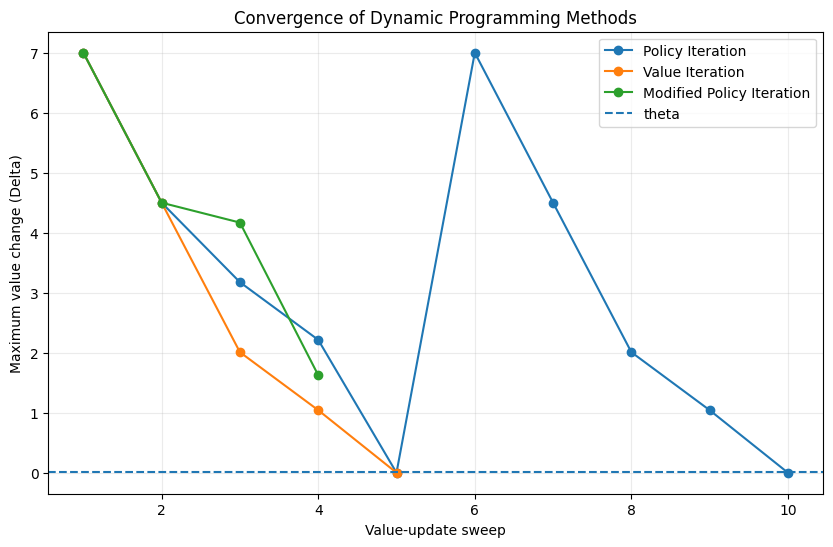

In [24]:
vi_deltas = [record['delta'] for record in vi_history]
pi_deltas = []
for outer in pi_history:
    pi_deltas.extend([record['delta'] for record in outer['eval_history']])
mpi_deltas = []
for outer in mpi_history:
    mpi_deltas.extend([record['delta'] for record in outer['eval_history']])
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(pi_deltas) + 1), pi_deltas, marker='o', label='Policy Iteration')
plt.plot(range(1, len(vi_deltas) + 1), vi_deltas, marker='o', label='Value Iteration')
plt.plot(range(1, len(mpi_deltas) + 1), mpi_deltas, marker='o', label='Modified Policy Iteration')
plt.axhline(theta, linestyle='--', label='theta')
plt.xlabel('Value-update sweep')
plt.ylabel('Maximum value change (Delta)')
plt.title('Convergence of Dynamic Programming Methods')
plt.legend()
plt.grid(alpha=0.25)
plt.show()

## 9.2 Final optimal policy on the MDP

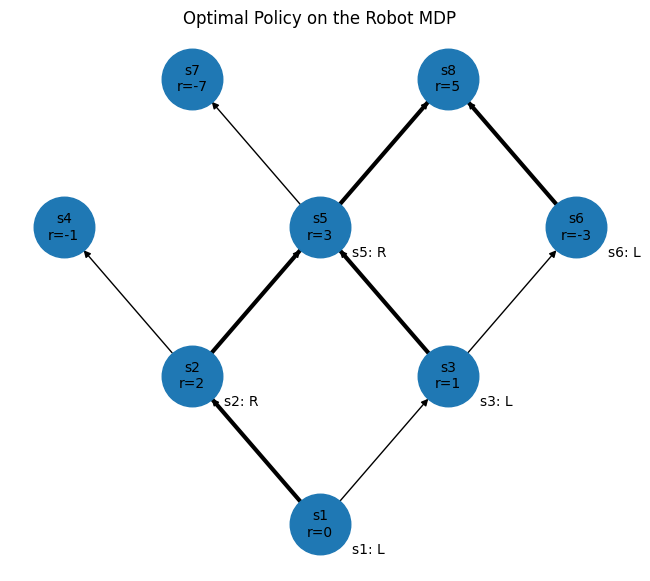

In [25]:
policy_edge = {'s1': {'L': 's2', 'R': 's3'}, 's2': {'L': 's4', 'R': 's5'}, 's3': {'L': 's5', 'R': 's6'}, 's5': {'L': 's7', 'R': 's8'}, 's6': {'L': 's8', 'R': 's8'}}
optimal_edges = []
for s in states:
    if s in terminal_states:
        continue
    a = policy_vi[state_index[s]]
    optimal_edges.append((s, policy_edge[s][a]))
plt.figure(figsize=(8, 7))
nx.draw_networkx(G, pos=pos, labels=labels, arrows=True, node_size=1900, font_size=10)
nx.draw_networkx_edges(G, pos=pos, edgelist=optimal_edges, width=3, arrows=True)
policy_labels = {s: f'{s}: {policy_vi[state_index[s]]}' for s in states if s not in terminal_states}
for s, text in policy_labels.items():
    x, y = pos[s]
    plt.text(x + 0.25, y - 0.2, text, fontsize=10)
plt.title('Optimal Policy on the Robot MDP')
plt.axis('off')
plt.show()


# 10. Main Takeaways

Dynamic Programming solves a known finite MDP by repeatedly applying Bellman updates.

**Policy Iteration** separates the process into full policy evaluation and greedy policy improvement.

**Value Iteration** applies the Bellman optimality update directly and extracts the greedy policy after the values converge.

**Modified Policy Iteration** performs only a limited number of evaluation sweeps before each policy improvement.

For this robot problem, all three methods reach the same optimal policy:

$$
\boxed{
\pi^*
=
[L,\;R,\;L,\;-,\;R,\;L,\;-,\;-]
}
$$

and the same optimal state-value function:

$$
\boxed{
V^*
\approx
[3.8847,\;4.4138,\;4.0888,\;-1,\;4.26,\;1.5,\;-7,\;5]
}
$$

This example shows the central DP idea clearly: use a known transition model to repeatedly evaluate future consequences and improve decisions until no better policy remains.
